# Gallery

This notebook is intended to showcase the possible plots in a way that is easily presentable in the repo.
Try to make templates as simple as possible and dependant on a minimal set of imports

## 1 basic single plot
### basic plot
Here is a basic plot that conforms to most of the rules outlined in `general_guide.md`. 
1. figsize is chosen to match journal expectation. Dpi is set to a reasonable value
2. Ticks are enabled on all axes and set to point inwards (this a preference potentially - old lithuanian style guide). 
3. Axies are clearly labeled and there is a title. Units are written in square brackets `[unit]` (optionally `/` can be used, but may be harder to interpret at a glance in some cases)

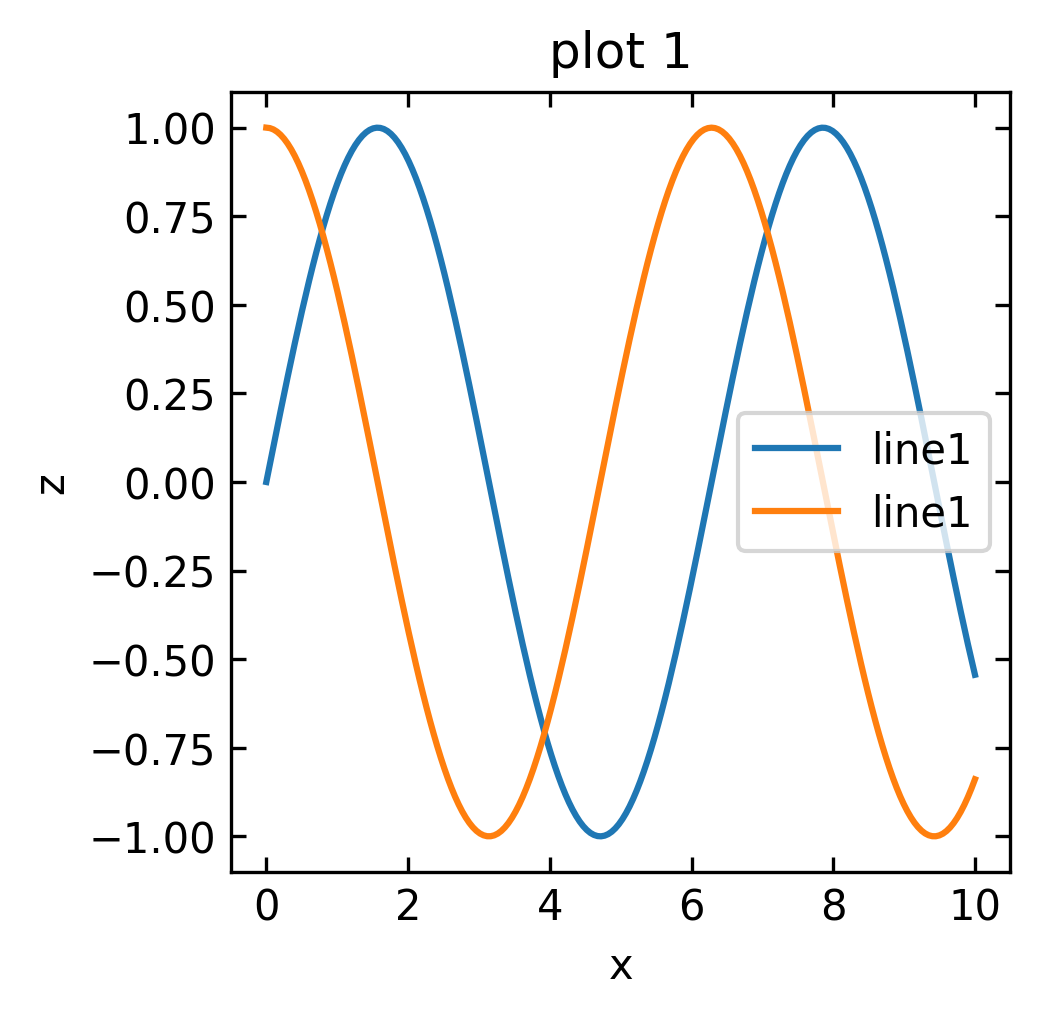

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 88 mm = 3.4646 in
mm_to_in = 1 / 25.4
fig_w = 88 * mm_to_in
fig_h = 88 * mm_to_in

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)

ax.set_title("plot 1")
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)
line1, = ax.plot(x, y1, lw=1.5, label="line1")
line2, = ax.plot(x, y2, lw=1.5, label="line1")

ax.set_xlabel("x")
ax.set_ylabel("z")

# Ticks on all axes, inward
ax.tick_params(direction="in", top=True, right=True, bottom=True, left=True, which="both")
# Turn on minnor tick ax.minorticks_on()

# Keep the plotting area square
ax.set_box_aspect(1)
# Or use set_aspect() to select any ratio 

# This is sometimes real pain to adjust. 
# Tick labels can change size etc. Sometimes this is better adjusted once
# all similar figures are "known"
fig.subplots_adjust(left=0.20, right=0.95, bottom=0.20, top=0.95)


plt.legend()

# Simple multiplot

Text(0, 0.5, '')

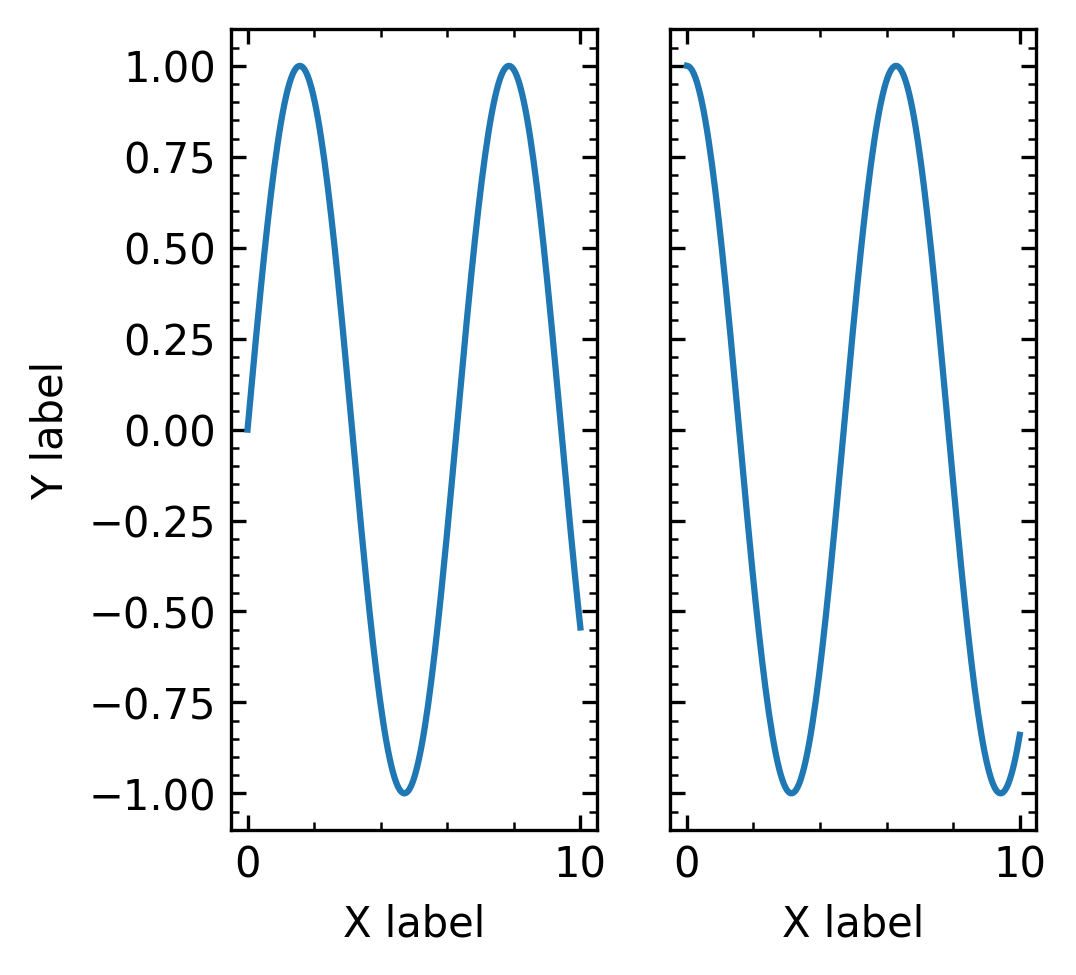

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 88 mm = 3.4646 in
mm_to_in = 1 / 25.4
fig_w = 88 * mm_to_in
fig_h = 88 * mm_to_in

def style_axes(ax):
    ax.tick_params(
        direction="in",
        top=True, right=True, bottom=True, left=True,
        which="both"
    )
    ax.minorticks_on()

x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

# 1) Two subplots in a row (no whitespace between)
fig_row, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(fig_w, fig_h), dpi=300, sharey=True
)

ax1.plot(x, y1, lw=1.5)
ax2.plot(x, y2, lw=1.5)

ax1.set_xlabel("X label")
ax1.set_ylabel("Y label")
ax2.set_xlabel("X label")
ax2.set_ylabel("Y label")

style_axes(ax1)
style_axes(ax2)

# Hide inner axis ticks/labels (right subplot y-axis)
ax2.tick_params(labelleft=False)
ax2.set_ylabel("")

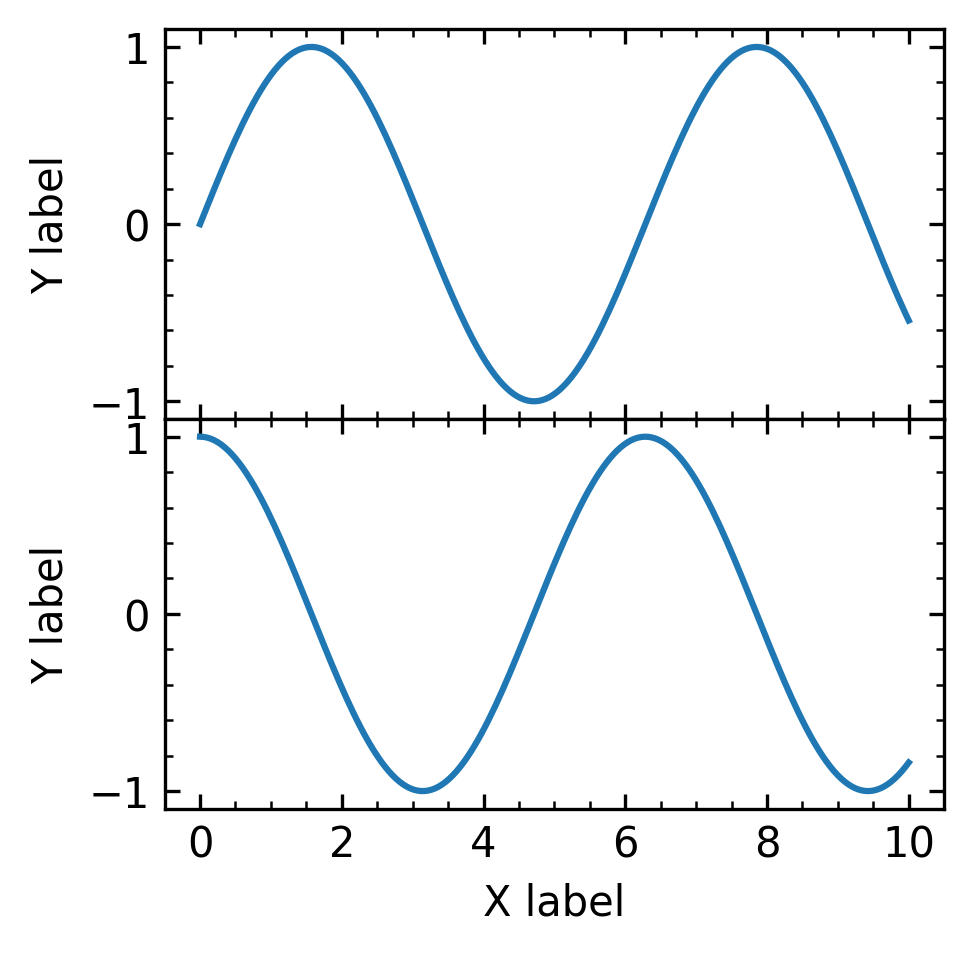

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 88 mm = 3.4646 in
mm_to_in = 1 / 25.4
fig_w = 88 * mm_to_in
fig_h = 88 * mm_to_in

def style_axes(ax):
    ax.tick_params(
        direction="in",
        top=True, right=True, bottom=True, left=True,
        which="both"
    )
    ax.minorticks_on()

x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig_col, (ax3, ax4) = plt.subplots(
    2, 1, figsize=(fig_w, fig_h), dpi=300, sharex=True
)

ax3.plot(x, y1, lw=1.5)
ax4.plot(x, y2, lw=1.5)

ax3.set_xlabel("X label")
ax3.set_ylabel("Y label")
ax4.set_xlabel("X label")
ax4.set_ylabel("Y label")

style_axes(ax3)
style_axes(ax4)

# Hide inner axis ticks/labels (top subplot x-axis)
ax3.tick_params(labelbottom=False)
ax3.set_xlabel("")

# Remove whitespace between subplots
fig_col.subplots_adjust(left=0.2, right=0.95, bottom=0.2, top=0.95, hspace=0)


## legend adjustments

Here are some common optional changes to the legend.

Legends are sometimes real pain in the neck. I is possible to adjust many properties of the automatic legend. But remember - you can draw anything on the plot. if it seems hard to change the automatic legend - just draw lines/symbols yourself :)

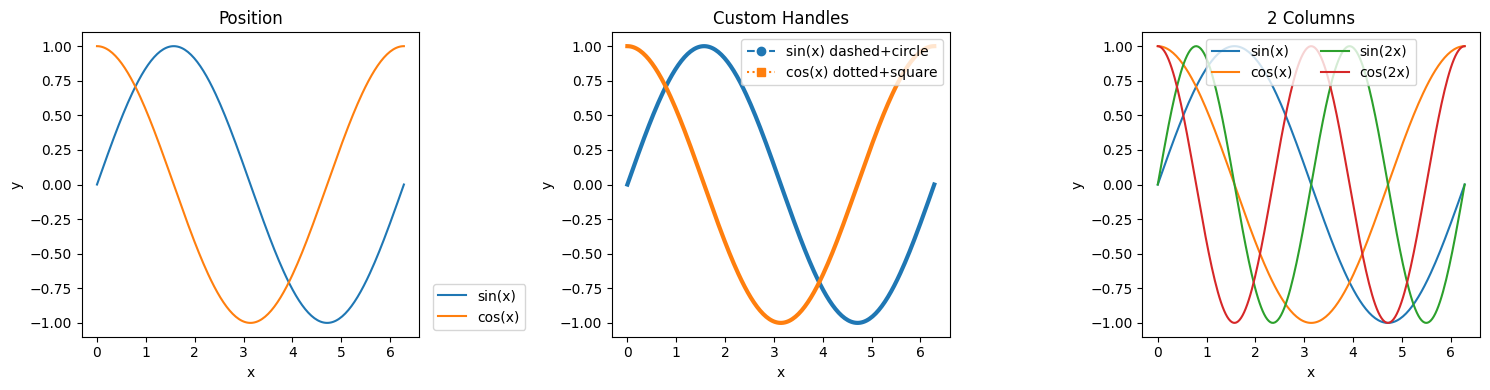

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x = np.linspace(0, 2*np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# 1) Legend position changed
axs[0].plot(x, y1, label="sin(x)")
axs[0].plot(x, y2, label="cos(x)")
# This may look simple never assume this did what you asked it to before checking the final saved plot :)
axs[0].legend(loc="lower left", bbox_to_anchor=(1.02, 0.0))
axs[0].set_title("Position")

# 2) Legend style/symbol different from plotted lines
axs[1].plot(x, y1, color="C0", linewidth=3, linestyle="-", label="_nolegend_")
axs[1].plot(x, y2, color="C1", linewidth=3, linestyle="-", label="_nolegend_")

# This is really heavy, but I struggle to come with a decent general example :)
custom_handles = [
    Line2D([0], [0], color="C0", marker="o", linestyle="--", label="sin(x) dashed+circle"),
    Line2D([0], [0], color="C1", marker="s", linestyle=":",  label="cos(x) dotted+square"),
]

axs[1].legend(handles=custom_handles, loc="upper right")
axs[1].set_title("Custom Handles")

# 3) You can have multi-column legends
axs[2].plot(x, np.sin(x), label="sin(x)")
axs[2].plot(x, np.cos(x), label="cos(x)")
axs[2].plot(x, np.sin(2*x), label="sin(2x)")
axs[2].plot(x, np.cos(2*x), label="cos(2x)")
axs[2].legend(ncol=2, loc="upper center")
axs[2].set_title("2 Columns")

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


# Binned Phase maps

2d histograms are in my opinion preffered to simple scatters. Tey are much faster and, appropriatly,  normalized they do not hide/misrepresent data as scatters sometimes do. 

(10.0, 3162277660.1683793)

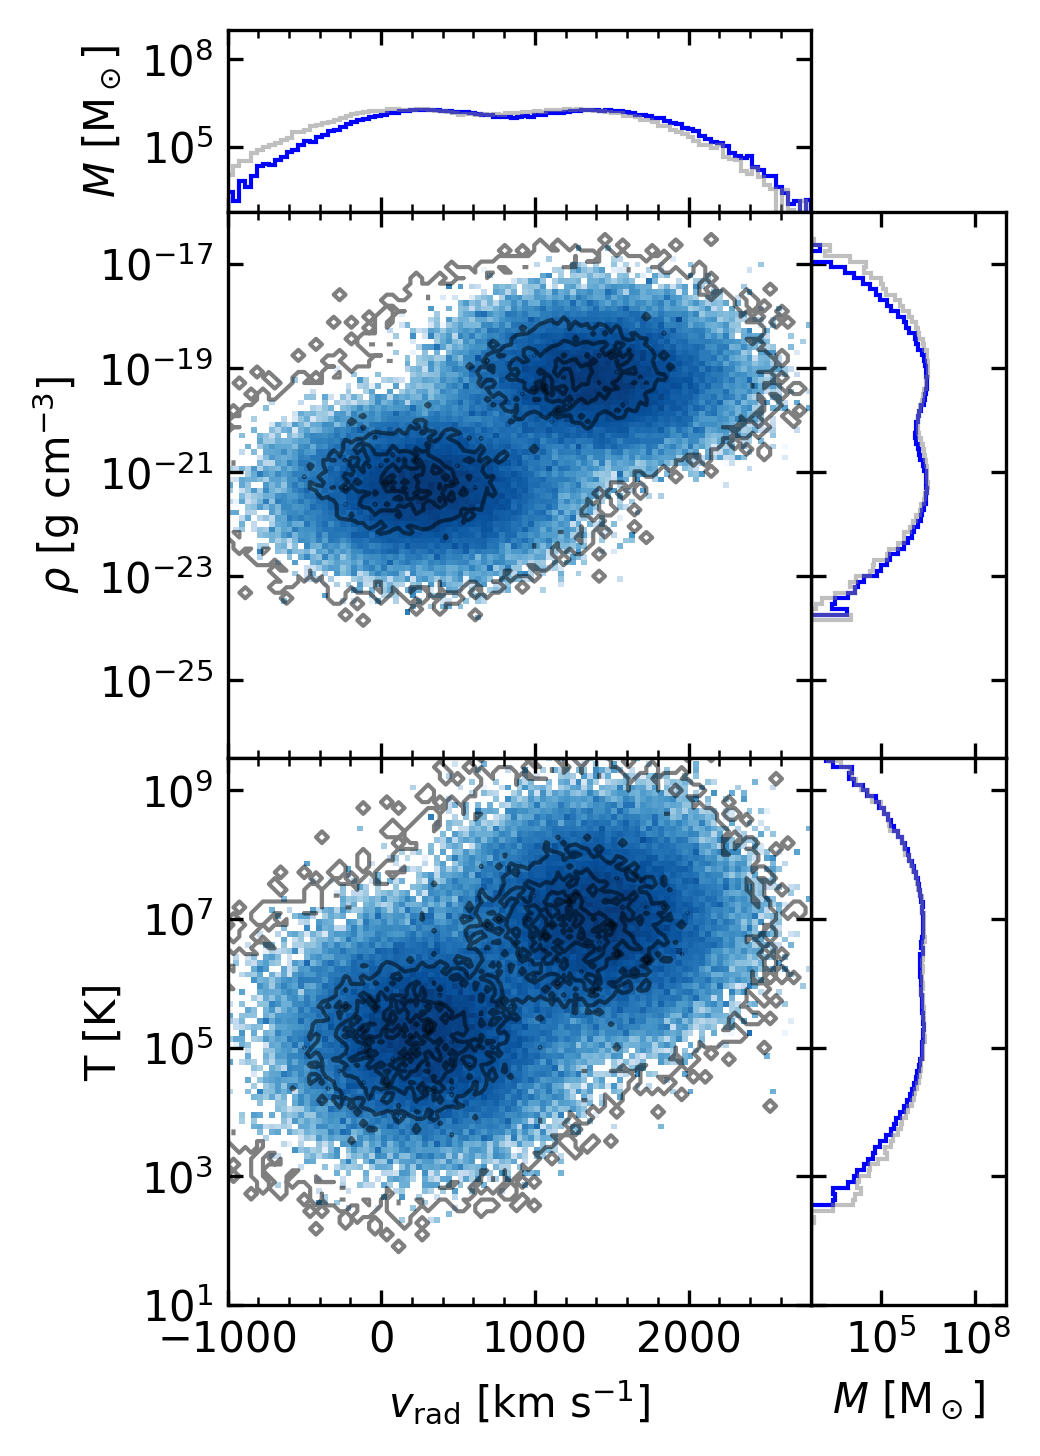

In [23]:

import numpy as np
import matplotlib.pyplot as plt


def style_axes(ax):
    ax.tick_params(direction="in", top=True, right=True, which="both")
    ax.minorticks_on()


# I asked AI to generate the synthetic data coz lazy
rng = np.random.default_rng(7)
n = 200_000

# Two-component synthetic data to create visible bimodality
rv_a = rng.normal(loc=300, scale=350, size=n // 2)
rv_b = rng.normal(loc=1400, scale=350, size=n // 2)
rv = np.concatenate([rv_a, rv_b])

log_rho_a = rng.normal(loc=-21.3, scale=0.6, size=n // 2)
log_rho_b = rng.normal(loc=-19.2, scale=0.6, size=n // 2)
rho = 10 ** np.concatenate([log_rho_a, log_rho_b])

log_t_a = rng.normal(loc=5.2, scale=0.7, size=n // 2)
log_t_b = rng.normal(loc=7.0, scale=0.7, size=n // 2)
temp = 10 ** np.concatenate([log_t_a, log_t_b])

mass = 10 ** rng.normal(loc=2.2, scale=0.6, size=n)

# Control sample for contours (slightly shifted)
rv0 = rv + rng.normal(loc=-150, scale=120, size=n)
rho0 = rho * 10 ** rng.normal(loc=0.2, scale=0.15, size=n)
temp0 = temp * 10 ** rng.normal(loc=-0.1, scale=0.2, size=n)
mass0 = mass * 10 ** rng.normal(loc=0.0, scale=0.2, size=n)



# ---- Double 2D-hist layout ----
fig = plt.figure(figsize=(3.46, 5.0), dpi=300)
grid = plt.GridSpec(7, 4, hspace=0.0, wspace=0.0, left=0.2, right=0.95, bottom=0.1, top=0.95)

# I am using descriptive axis labels 
ax_vel_hist = fig.add_subplot(grid[0, 0:3])
ax_rho_hist = fig.add_subplot(grid[1:4, -1])
ax_temp_hist = fig.add_subplot(grid[4:, -1])

ax_rho_map = fig.add_subplot(grid[1:4, 0:3])
ax_temp_map = fig.add_subplot(grid[4:, 0:3])

# we can loop over ax objects
for axis in [ax_vel_hist, ax_rho_hist, ax_temp_hist, ax_rho_map, ax_temp_map]:
    style_axes(axis)

ax_temp_map.set_ylabel("T [K]")
ax_temp_map.set_xlabel(r"$v_{\rm rad}$ [km s$^{-1}$]")
ax_rho_map.set_ylabel(r"$\rho$ [g cm$^{-3}$]")
ax_rho_map.set_xlabel(r"$v_{\rm rad}$ [km s$^{-1}$]")
ax_vel_hist.set_ylabel(r"$M$ [M$_\odot$]")
ax_temp_hist.set_xlabel(r"$M$ [M$_\odot$]")

ax_vel_hist.tick_params(labelbottom=False)
ax_rho_map.tick_params(labelbottom=False)
ax_rho_hist.tick_params(labelleft=False, labelbottom=False)
ax_temp_hist.tick_params(labelleft=False)

ax_rho_map.set_yscale("log")
ax_temp_map.set_yscale("log")
ax_temp_hist.set_yscale("log")
ax_rho_hist.set_yscale("log")

bins_v_rho = [np.linspace(-1000, 2800, 100), np.logspace(-26.5, -16, 100)]
bins_v_temp = [np.linspace(-1000, 2800, 100), np.logspace(1, 10, 100)]

ax_rho_map.hist2d(rv, rho, bins=bins_v_rho, cmap="Blues", norm="log", weights=mass)
# countours are nt the same as binnd data and are a bit harder to do in python
# I am using the data from histograma  - we can think of this as counts = f(X, Y)
hist0, xedges0, yedges0 = np.histogram2d(rv0, rho0, bins=bins_v_rho, weights=mass0)
X0, Y0 = np.meshgrid(xedges0, yedges0)
ax_rho_map.contour(X0[:-1, :-1], Y0[:-1, :-1], hist0.T, colors="black", linewidths=1, levels=5, alpha=0.5)

ax_vel_hist.hist(rv, bins=bins_v_rho[0], orientation="vertical", color="b", histtype="step", log=True, weights=mass)
ax_rho_hist.hist(rho, bins=bins_v_rho[1], orientation="horizontal", color="b", histtype="step", log=True, weights=mass)
ax_vel_hist.hist(rv0, bins=bins_v_rho[0], orientation="vertical", color="gray", histtype="step", log=True, alpha=0.5, weights=mass0)
ax_rho_hist.hist(rho0, bins=bins_v_rho[1], orientation="horizontal", color="gray", histtype="step", log=True, alpha=0.5, weights=mass0)

ax_temp_map.hist2d(rv, temp, bins=bins_v_temp, cmap="Blues", norm="log", weights=mass)
hist1, xedges1, yedges1 = np.histogram2d(rv0, temp0, bins=bins_v_temp, weights=mass0)
X1, Y1 = np.meshgrid(xedges1, yedges1)
ax_temp_map.contour(X1[:-1, :-1], Y1[:-1, :-1], hist1.T, colors="black", linewidths=1, levels=5, alpha=0.5)

ax_temp_hist.hist(temp, bins=bins_v_temp[1], orientation="horizontal", color="b", histtype="step", log=True, weights=mass)
ax_temp_hist.hist(temp0, bins=bins_v_temp[1], orientation="horizontal", color="gray", histtype="step", log=True, alpha=0.5, weights=mass0)

ax_rho_hist.set_xlim(600, 1e9)
ax_rho_hist.set_ylim(10**-26.5, 10**-16)
ax_temp_hist.set_xlim(600, 1e9)
ax_vel_hist.set_ylim(600, 1e9)
ax_vel_hist.set_xlim(-1000, 2800)
ax_temp_map.set_ylim(1e1, 10**9.5)
ax_temp_hist.set_ylim(1e1, 10**9.5)